In [1]:
import os
import gc
import time
import timm
import math
import random
import warnings
import numpy as np
import pandas as pd
import soundfile as sf

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

from tqdm import tqdm
from pathlib import Path
from scipy.signal import resample_poly
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# /kaggle/input/competitions/birdclef-2026/

In [14]:
KAGGLE_PATH = Path("/kaggle/input")
DATA_PATH = KAGGLE_PATH / "competitions/birdclef-2026"
MODELS_PATH = KAGGLE_PATH / "datasets/vladimirsydor/bird-clef-2025-pretrained-models"
# MODEL_PATH = MODELS_PATH / "eca_nfnet_l0_pretrain_from_bigXCV2_best.ckpt"
MODEL_PATH = MODELS_PATH / "tf_efficientnetv2_s_in21k_pretrain_from_bigXCV2_best.ckpt"
TRAIN_CSV = DATA_PATH / 'train.csv'
TAXONOMY_CSV = DATA_PATH / 'taxonomy.csv'
SAMPLE_SUB = DATA_PATH / 'sample_submission.csv'
TRAIN_AUDIO = DATA_PATH / 'train_audio'
SC_LABELS_CSV = DATA_PATH / 'train_soundscapes_labels.csv'
SC_AUDIO_DIR = DATA_PATH / 'train_soundscapes'
TEST_DIR = DATA_PATH / 'test_soundscapes'
OUTPUT_DIR = Path('/kaggle/working')
WEIGHTS_DIR = OUTPUT_DIR / 'fold_weights'

N_CLASSES = 234
RANDOM_SEED = 42
IMG_SIZE = 224

EPOCHS = 10
BATCH_SIZE = 32
LR = 5e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 4
N_FOLDS = 5
MIN_CLASS_SAMPLES_FOR_VAL = 14
TRAIN_ONLY_FOLD = -1

SR = 32000
DURATION = 5
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 320
FMIN = 50
FMAX = 14000

DEBUG = False

# FOLDS_TO_RUN = [1]
# FOLDS_TO_RUN = [0, 1, 2, 3, 4]
FOLDS_TO_RUN = [4]
# FOLDS_TO_RUN = None
EARLY_STOPPING = True
PATIENCE = 1

# augmentation
USE_MIXUP = True
MIXUP_ALPHA = 0.4
USE_SPECAUGMENT = True
SECONDARY_LABEL_WEIGHT = 0.3
SOUNDSCAPE_LABEL_WEIGHT = 1.0
USE_SOUNDSCAPE_LABELS = True

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

device: cuda
GPU: Tesla T4
memory: 15.6 GB


In [4]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

# Load Dataset

In [5]:
df = pd.read_csv(TRAIN_CSV)
taxonomy = pd.read_csv(TAXONOMY_CSV)
sample_sub = pd.read_csv(SAMPLE_SUB)
sc_labels = pd.read_csv(SC_LABELS_CSV)

SPECIES_COLS = [c for c in sample_sub.columns if c != 'row_id']
NUM_CLASSES = len(SPECIES_COLS)
label2idx = {label: idx for idx, label in enumerate(SPECIES_COLS)}
idx2label = {idx: label for label, idx in label2idx.items()}

print(f'train rows  : {len(df):,}')
print(f'num classes : {NUM_CLASSES}')
print(f'test files  : {len(list(TEST_DIR.glob("*.ogg")))}')

# Primary training data
df['label_idx'] = df['primary_label'].map(label2idx).fillna(-1).astype(int)
df_train = df[df['label_idx'] >= 0].reset_index(drop=True)

# Parse secondary labels
def parse_secondary(s):
    if pd.isna(s) or s in ['[]', '']:
        return []
    items = str(s).strip('[]').replace("'", '').replace('"', '').split(',')
    idxs = [label2idx[i.strip()] for i in items if i.strip() in label2idx]
    return sorted(set(idxs))


def parse_soundscape_labels(s):
    if pd.isna(s) or s == '':
        return []
    labels = [x.strip() for x in str(s).split(';') if x.strip()]
    idxs = [label2idx[x] for x in labels if x in label2idx]
    return sorted(set(idxs))


def parse_time_to_seconds(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if s == '':
        return None
    try:
        return float(s)
    except Exception:
        pass
    if ':' in s:
        parts = s.split(':')
        try:
            parts = [float(p) for p in parts]
        except Exception:
            return None
        if len(parts) == 3:
            h, m, sec = parts
            return h * 3600.0 + m * 60.0 + sec
        if len(parts) == 2:
            m, sec = parts
            return m * 60.0 + sec
    return None


df_train['secondary_idxs'] = df_train['secondary_labels'].apply(parse_secondary)
df_train['all_label_idxs'] = df_train.apply(
    lambda row: [int(row['label_idx'])] + [s for s in row['secondary_idxs'] if s != int(row['label_idx'])],
    axis=1,
)
df_train['is_soundscape'] = False
df_train['sampling_label_idx'] = df_train['label_idx']
df_train['start_sec'] = np.nan
df_train['end_sec'] = np.nan

# Add soundscape labels row-by-row (each row = one labeled time segment)
if USE_SOUNDSCAPE_LABELS:
    sc_labels['filename'] = sc_labels['filename'].astype(str)
    sc_labels['label_idxs'] = sc_labels['primary_label'].astype(str).apply(parse_soundscape_labels)
    sc_labels = sc_labels[sc_labels['label_idxs'].map(len) > 0].copy()

    start_col = next((c for c in ['start', 'start_time', 'start_sec', 'seconds_start'] if c in sc_labels.columns), None)
    end_col = next((c for c in ['end', 'end_time', 'end_sec', 'seconds_end'] if c in sc_labels.columns), None)

    sc_rows = []
    for _, row in sc_labels.iterrows():
        fn = str(row.get('filename', ''))
        labels = row['label_idxs']

        start_sec = parse_time_to_seconds(row[start_col]) if start_col else None
        end_sec = parse_time_to_seconds(row[end_col]) if end_col else None

        if start_sec is None and end_sec is None:
            start_sec, end_sec = 0.0, float(DURATION)
        elif start_sec is None:
            start_sec = max(0.0, float(end_sec) - float(DURATION))
        elif end_sec is None:
            end_sec = float(start_sec) + float(DURATION)

        if end_sec <= start_sec:
            end_sec = float(start_sec) + float(DURATION)

        if fn and labels and (SC_AUDIO_DIR / fn).exists():
            sc_rows.append({
                'filename': fn,
                'label_idx': labels[0],
                'secondary_idxs': labels[1:],
                'all_label_idxs': labels,
                'sampling_label_idx': labels[0],
                'is_soundscape': True,
                'start_sec': float(start_sec),
                'end_sec': float(end_sec),
                'fold': TRAIN_ONLY_FOLD,
            })

    df_sc = pd.DataFrame(sc_rows)
    print(f'soundscape rows added: {len(df_sc):,}')
else:
    df_sc = pd.DataFrame(columns=[
        'filename', 'label_idx', 'secondary_idxs', 'all_label_idxs', 'sampling_label_idx',
        'is_soundscape', 'start_sec', 'end_sec', 'fold'
    ])

print(f'total primary clips: {len(df_train):,}')



train rows  : 35,549
num classes : 234
test files  : 0
soundscape rows added: 1,478
total primary clips: 35,549


In [6]:
def assign_balanced_folds_single(df_in, label_col, n_folds, seed):
    fold_arr = np.full(len(df_in), TRAIN_ONLY_FOLD, dtype=int)
    rng = np.random.default_rng(seed)

    for _, idx in df_in.groupby(label_col).indices.items():
        idx = np.array(list(idx), dtype=int)
        rng.shuffle(idx)
        fold_arr[idx] = np.arange(len(idx), dtype=int) % n_folds

    return fold_arr


def assign_multilabel_folds(df_in, labels_col, n_folds, n_classes, seed):
    """Greedy multi-label fold assignment (best-effort for rare labels)."""
    n_samples = len(df_in)
    if n_samples == 0:
        return np.array([], dtype=int)

    labels_list = [list(map(int, labels)) if isinstance(labels, list) else [] for labels in df_in[labels_col].tolist()]

    label_freq = np.zeros(n_classes, dtype=float)
    for labels in labels_list:
        for lab in labels:
            label_freq[lab] += 1.0

    fold_sizes = np.zeros(n_folds, dtype=float)
    fold_label_counts = np.zeros((n_folds, n_classes), dtype=float)
    assignments = np.full(n_samples, -1, dtype=int)

    rng = np.random.default_rng(seed)

    def rarity_key(labels):
        if not labels:
            return 1e9
        return min(label_freq[l] for l in labels)

    order = list(range(n_samples))
    rng.shuffle(order)
    order.sort(key=lambda i: (rarity_key(labels_list[i]), -len(labels_list[i])))

    target_fold_size = n_samples / n_folds
    target_per_label = label_freq / n_folds

    for i in order:
        labels = labels_list[i]
        best_fold, best_score = 0, None

        for fold in range(n_folds):
            size_before = abs(fold_sizes[fold] - target_fold_size)
            size_after = abs((fold_sizes[fold] + 1.0) - target_fold_size)
            size_delta = size_after - size_before

            label_delta = 0.0
            for lab in labels:
                tgt = max(target_per_label[lab], 1e-6)
                before = abs(fold_label_counts[fold, lab] - target_per_label[lab]) / tgt
                after = abs((fold_label_counts[fold, lab] + 1.0) - target_per_label[lab]) / tgt
                label_delta += (after - before)

            score = label_delta + 0.2 * size_delta

            if best_score is None or score < best_score - 1e-12:
                best_score = score
                best_fold = fold
            elif abs(score - best_score) <= 1e-12 and fold_sizes[fold] < fold_sizes[best_fold]:
                best_fold = fold

        assignments[i] = best_fold
        fold_sizes[best_fold] += 1.0
        for lab in labels:
            fold_label_counts[best_fold, lab] += 1.0

    return assignments


# Main train clips: keep undersampled classes as train-only
class_counts = df_train['label_idx'].value_counts()
train_only_classes = class_counts[class_counts < MIN_CLASS_SAMPLES_FOR_VAL].index

df_train['fold'] = TRAIN_ONLY_FOLD
eligible_mask = ~df_train['label_idx'].isin(train_only_classes)
if eligible_mask.any():
    df_cv = df_train.loc[eligible_mask].copy()
    df_cv['fold'] = assign_balanced_folds_single(df_cv, 'label_idx', N_FOLDS, RANDOM_SEED)
    df_train.loc[df_cv.index, 'fold'] = df_cv['fold'].astype(int)

# Soundscapes: split by all labels (multi-label stratification, best-effort)
if USE_SOUNDSCAPE_LABELS and len(df_sc) > 0:
    df_sc['fold'] = assign_multilabel_folds(
        df_sc,
        labels_col='all_label_idxs',
        n_folds=N_FOLDS,
        n_classes=NUM_CLASSES,
        seed=RANDOM_SEED + 1001,
    )

if DEBUG:
    df_train = df_train.sample(min(400, len(df_train)), random_state=RANDOM_SEED).reset_index(drop=True)
    if len(df_sc) > 0:
        df_sc = df_sc.sample(min(120, len(df_sc)), random_state=RANDOM_SEED).reset_index(drop=True)
    print(f'DEBUG mode — train={len(df_train)} soundscapes={len(df_sc)}')

num_train_only_classes = len(train_only_classes)
num_train_only_rows = int((df_train['fold'] == TRAIN_ONLY_FOLD).sum())
print(f'{N_FOLDS}-fold split done.')
print(f'class threshold for val: >= {MIN_CLASS_SAMPLES_FOR_VAL} clips/class')
print(f'train-only classes: {num_train_only_classes:,}')
print(f'train-only rows   : {num_train_only_rows:,}')

for fold in range(N_FOLDS):
    fold_rows = int((df_train['fold'] == fold).sum())
    print(f'  fold {fold}: primary val rows = {fold_rows:,}')

if USE_SOUNDSCAPE_LABELS and len(df_sc) > 0:
    print('soundscape fold sizes:')
    for fold in range(N_FOLDS):
        sc_rows = int((df_sc['fold'] == fold).sum())
        print(f'  fold {fold}: soundscape val rows = {sc_rows:,}')

    sc_label_set = {lab for labels in df_sc['all_label_idxs'] for lab in labels}
    print(f'soundscape unique labels: {len(sc_label_set):,}')

5-fold split done.
class threshold for val: >= 14 clips/class
train-only classes: 30
train-only rows   : 154
  fold 0: primary val rows = 7,147
  fold 1: primary val rows = 7,113
  fold 2: primary val rows = 7,088
  fold 3: primary val rows = 7,045
  fold 4: primary val rows = 7,002
soundscape fold sizes:
  fold 0: soundscape val rows = 295
  fold 1: soundscape val rows = 295
  fold 2: soundscape val rows = 296
  fold 3: soundscape val rows = 296
  fold 4: soundscape val rows = 296
soundscape unique labels: 75


In [7]:
def load_and_crop(filepath, sr=SR, duration=DURATION, is_train=True) -> np.ndarray:
    target_len = int(sr * duration)
    try:
        wav, file_sr = torchaudio.load(str(filepath))
        wav = wav.mean(dim=0)
        if file_sr != sr:
            wav = F.resample(wav, file_sr, sr)
    except Exception as e:
        print(e)
        return np.zeros(target_len, dtype=np.float32)

    y = wav.numpy()
    if len(y) == 0:
        return np.zeros(target_len, dtype=np.float32)
    if len(y) < target_len:
        y = np.tile(y, math.ceil(target_len / len(y)))
    if len(y) > target_len:
        start = random.randint(0, len(y) - target_len) if is_train \
                else (len(y) - target_len) // 2
        y = y[start: start + target_len]
    return y.astype(np.float32)


def load_exact_window(filepath, start_sec, end_sec,
                      sr=SR, duration=DURATION) -> np.ndarray:
    target_len = int(sr * duration)

    if start_sec is None and end_sec is None:
        start_sec, end_sec = 0.0, float(duration)
    elif start_sec is None:
        start_sec = max(0.0, float(end_sec) - float(duration))
    elif end_sec is None:
        end_sec = float(start_sec) + float(duration)
    if float(end_sec) <= float(start_sec):
        end_sec = float(start_sec) + float(duration)

    try:
        wav, file_sr = torchaudio.load(str(filepath))
        wav = wav.mean(dim=0)
        start = int(start_sec * file_sr) if start_sec is not None else 0
        end = int(end_sec * file_sr) if end_sec is not None else start + int(duration * file_sr)
        if end <= start:
            end = start + int(duration * file_sr)
        wav = wav[start:end]
        if file_sr != sr:
            wav = F.resample(wav, file_sr, sr)
        y = wav.numpy()
    except Exception as e:
        print(e)
        y = np.zeros(target_len, dtype=np.float32)

    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    elif len(y) > target_len:
        y = y[:target_len]
    return y.astype(np.float32)


mel_transform = None


def get_mel_transform(sr=SR, device='cpu'):
    global mel_transform
    if mel_transform is None:
        mel_transform = T.MelSpectrogram(
            sample_rate=SR,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            n_mels=N_MELS,
            f_min=FMIN,
            f_max=FMAX,
            power=2.0,
            center=True,
            pad_mode='constant',
            norm='slaney',
            mel_scale='slaney',
        ).to(device)
    return mel_transform


def audio_to_melspec(y: np.ndarray, sr=SR, device='cpu') -> np.ndarray:
    wav = torch.from_numpy(y).unsqueeze(0).to(device)

    mel_transform = get_mel_transform(sr, device)
    mel = mel_transform(wav)

    mel_db = T.AmplitudeToDB(stype='power', top_db=None)(mel)
    mel_db = mel_db.squeeze(0)
    mn = mel_db.min()
    mx = mel_db.max()
    mel_db = (mel_db - mn) / (mx - mn + 1e-6)

    return mel_db.cpu().numpy().astype(np.float32)


def spec_augment(mel, freq_mask_param=30, time_mask_param=40, n_freq_masks=2, n_time_masks=2):
    mel = mel.copy()
    num_mels, time_steps = mel.shape
    for _ in range(n_freq_masks):
        f  = random.randint(0, freq_mask_param)
        f0 = random.randint(0, max(0, num_mels - f))
        mel[f0:f0+f, :] = 0.0
    for _ in range(n_time_masks):
        t  = random.randint(0, time_mask_param)
        t0 = random.randint(0, max(0, time_steps - t))
        mel[:, t0:t0+t] = 0.0
    return mel



In [8]:
class BirdDataset(Dataset):
    def __init__(self, df, audio_dir, sc_audio_dir=None, is_train=True):
        self.df = df.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.sc_audio_dir = Path(sc_audio_dir) if sc_audio_dir else None
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = int(row['label_idx'])
        is_sc = bool(row.get('is_soundscape', False))
        filepath = (self.sc_audio_dir if is_sc and self.sc_audio_dir else self.audio_dir) / row['filename']

        if is_sc:
            start_sec = row.get('start_sec', np.nan)
            end_sec = row.get('end_sec', np.nan)
            start_sec = None if pd.isna(start_sec) else float(start_sec)
            end_sec = None if pd.isna(end_sec) else float(end_sec)
            y = load_exact_window(str(filepath), start_sec=start_sec, end_sec=end_sec, duration=DURATION)
        else:
            y = load_and_crop(str(filepath), is_train=self.is_train)

        mel = audio_to_melspec(y)

        if self.is_train and USE_SPECAUGMENT:
            mel = spec_augment(mel)

        mel_tensor = torch.from_numpy(mel).unsqueeze(0)
        mel_tensor = F.interpolate(
            mel_tensor.unsqueeze(0), size=(IMG_SIZE, IMG_SIZE),
            mode='bilinear', align_corners=False
        ).squeeze(0)

        all_label_idxs = row.get('all_label_idxs', [])
        if not isinstance(all_label_idxs, list):
            all_label_idxs = [label] if label >= 0 else []

        target = torch.zeros(NUM_CLASSES, dtype=torch.float32)
        if is_sc:
            for sidx in all_label_idxs:
                target[sidx] = SOUNDSCAPE_LABEL_WEIGHT
        else:
            if label >= 0:
                target[label] = 1.0
            for sidx in all_label_idxs:
                if sidx != label and target[sidx] == 0.0:
                    target[sidx] = SECONDARY_LABEL_WEIGHT

        return mel_tensor, target



# Load Model

In [9]:
def fix_keys(state_dict):
    new_sd = {}
    for k, v in state_dict.items():
        k = k.replace('model.', '')
        k = k.replace('stem_conv', 'stem.conv')
        k = k.replace('stages_', 'stages.')

        new_sd[k] = v
    return new_sd


class BirdModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            # 'eca_nfnet_l0',
            'tf_efficientnetv2_s.in21k',
            pretrained=False,
            in_chans=1,
            num_classes=N_CLASSES,
        )
        ckpt = torch.load(MODEL_PATH, map_location='cpu')
        state_dict = ckpt.get('state_dict', ckpt)
        state_dict = fix_keys(state_dict)
        
        missing, unexpected = self.backbone.load_state_dict(state_dict, strict=False)
        
        print("Missing:", len(missing))
        print("Unexpected:", len(unexpected))

    def forward(self, x):
        return self.backbone(x)

# Training

In [10]:
def mixup_data(x, y, alpha=MIXUP_ALPHA):
    if alpha <= 0:
        return x, y
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], lam * y + (1 - lam) * y[idx]


criterion = nn.BCEWithLogitsLoss()

In [11]:
def train_one_epoch(model, loader, optimizer, scheduler, scaler, device):
    model.train()
    total_loss, n_batches = 0, 0
    pbar = tqdm(loader, desc="Training...")
    for batch_idx, (images, targets) in enumerate(pbar):
        images  = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        if USE_MIXUP:
            images, targets = mixup_data(images, targets)
        optimizer.zero_grad()
        with autocast():
            loss = criterion(model(images), targets)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        if scheduler:
            scheduler.step()
        total_loss += loss.item()
        n_batches  += 1
        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "avg": f"{(total_loss / n_batches):.4f}"
        })
    return total_loss / n_batches


def competition_macro_auc(y_true, y_pred):
    """Kaggle-like macro ROC-AUC: score only classes with at least one positive."""
    solution_sums = y_true.sum(axis=0)
    scored = solution_sums > 0

    if not scored.any():
        return 0.0, scored

    try:
        auc = roc_auc_score(y_true[:, scored], y_pred[:, scored], average='macro')
        return float(auc), scored
    except ValueError:
        # Local CV safety: drop classes without negatives in this fold.
        pos = y_true[:, scored].sum(axis=0)
        neg = y_true.shape[0] - pos
        safe = (pos > 0) & (neg > 0)
        if not safe.any():
            return 0.0, scored
        auc = roc_auc_score(y_true[:, scored][:, safe], y_pred[:, scored][:, safe], average='macro')
        return float(auc), scored


@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss, n_batches = 0, 0
    pbar = tqdm(loader, desc="Validating...")
    for images, targets in pbar:
        images  = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        with autocast():
            logits = model(images)
            loss   = criterion(logits, targets)
        all_preds.append(torch.sigmoid(logits).float().cpu().numpy())
        all_labels.append(targets.float().cpu().numpy())
        total_loss += loss.item()
        n_batches  += 1
        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "avg": f"{(total_loss / n_batches):.4f}"
        })

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # Convert soft BCE targets (e.g., 0.3 for secondary) to binary presence/absence for AUC.
    y_true = (all_labels > 0.0).astype(np.int32)

    auc, scored_mask = competition_macro_auc(y_true, all_preds)
    n_unscored = int(NUM_CLASSES - scored_mask.sum())
    if n_unscored > 0:
        print(f'  note: {n_unscored} classes have no positives in val (excluded from AUC)')

    return total_loss / n_batches, auc



In [15]:
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

fold_best_paths = []
cv_results = []
fold_histories = {}

folds = range(N_FOLDS) if FOLDS_TO_RUN is None else FOLDS_TO_RUN

for fold in folds:
    print('\n' + '=' * 60)
    print(f'Fold {fold + 1}/{N_FOLDS}')
    print('=' * 60)

    tr_main_df = df_train[(df_train['fold'] != fold)].reset_index(drop=True)
    val_main_df = df_train[df_train['fold'] == fold].reset_index(drop=True)

    if USE_SOUNDSCAPE_LABELS and len(df_sc) > 0:
        tr_sc_df = df_sc[df_sc['fold'] != fold].reset_index(drop=True)
        val_sc_df = df_sc[df_sc['fold'] == fold].reset_index(drop=True)
        tr_df = pd.concat([tr_main_df, tr_sc_df], ignore_index=True)
        val_df = pd.concat([val_main_df, val_sc_df], ignore_index=True)
    else:
        tr_df = tr_main_df
        val_df = val_main_df

    train_ds = BirdDataset(tr_df, TRAIN_AUDIO, SC_AUDIO_DIR, is_train=True)
    val_ds = BirdDataset(val_df, TRAIN_AUDIO, SC_AUDIO_DIR, is_train=False)

    label_freq = np.zeros(NUM_CLASSES, dtype=np.float64)
    for labels in tr_df['all_label_idxs']:
        if isinstance(labels, list):
            for lab in labels:
                label_freq[int(lab)] += 1.0

    def sample_weight(labels):
        if not isinstance(labels, list) or len(labels) == 0:
            return 1.0
        inv = [1.0 / max(label_freq[int(lab)], 1.0) for lab in labels]
        return float(np.mean(inv))

    sample_weights = tr_df['all_label_idxs'].apply(sample_weight).astype(np.float64).values
    train_sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

    labels_present = int((label_freq > 0).sum())
    print(f'train: {len(tr_df):,}  val: {len(val_df):,}')
    if USE_SOUNDSCAPE_LABELS and len(df_sc) > 0:
        print(f'  includes soundscapes -> train: {len(tr_sc_df):,}  val: {len(val_sc_df):,}')
    print(f'weighted sampler labels present: {labels_present:,}')
    print(f'train batches: {len(train_loader)}  val batches: {len(val_loader)}')

    model = BirdModel().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    total_steps = EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler = GradScaler()

    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
    best_auc = -1.0
    best_epoch = 0
    best_path = WEIGHTS_DIR / f'best_model_fold_{fold}.pth'

    no_improve_epochs = 0

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        print(f'\nepoch {epoch}/{EPOCHS}')

        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, scaler, device)
        val_loss, val_auc = validate(model, val_loader, device)

        elapsed = time.time() - t0
        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)

        print(f'  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  '
              f'val_auc={val_auc:.4f}  lr={current_lr:.2e}  ({elapsed:.0f}s)')

        if val_auc > best_auc:
            best_auc = val_auc
            best_epoch = epoch
            no_improve_epochs = 0
            torch.save(model.state_dict(), best_path)
            print(f'  new best saved -> {best_path.name} (auc={best_auc:.4f})')
        else:
            no_improve_epochs += 1
            print(f'  no improvement ({no_improve_epochs}/{PATIENCE})')

        gc.collect()

        if EARLY_STOPPING and no_improve_epochs >= PATIENCE:
            print(f'  early stopping triggered at epoch {epoch}')
            break

    fold_histories[fold] = history
    fold_best_paths.append(best_path)
    cv_results.append({
        'fold': fold,
        'best_auc': best_auc,
        'best_epoch': best_epoch,
        'train_rows': len(tr_df),
        'val_rows': len(val_df),
        'weights': str(best_path),
    })

    del model, optimizer, scheduler, scaler, train_loader, val_loader
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

cv_results_df = pd.DataFrame(cv_results)
print('\nCV done!')
print(cv_results_df[['fold', 'best_auc', 'best_epoch', 'train_rows', 'val_rows']])
print(f"mean AUC: {cv_results_df['best_auc'].mean():.4f} ± {cv_results_df['best_auc'].std(ddof=0):.4f}")


Fold 5/5
train: 29,729  val: 7,298
  includes soundscapes -> train: 1,182  val: 296
weighted sampler labels present: 234
train batches: 929  val batches: 229
Missing: 7
Unexpected: 0

epoch 1/10


Validating...: 100%|██████████| 229/229 [01:44<00:00,  2.19it/s, loss=0.0312, avg=0.0202]


  note: 23 classes have no positives in val (excluded from AUC)
  train_loss=0.0954  val_loss=0.0202  val_auc=0.9094  lr=4.97e-04  (546s)
  new best saved -> best_model_fold_4.pth (auc=0.9094)

epoch 2/10


Validating...: 100%|██████████| 229/229 [01:43<00:00,  2.22it/s, loss=0.0144, avg=0.0138]


  note: 23 classes have no positives in val (excluded from AUC)
  train_loss=0.0190  val_loss=0.0138  val_auc=0.9409  lr=4.70e-04  (527s)
  new best saved -> best_model_fold_4.pth (auc=0.9409)

epoch 3/10


...

  note: 23 classes have no positives in val (excluded from AUC)
  train_loss=0.0124  val_loss=0.0095  val_auc=0.9640  lr=5.27e-05  (542s)
  new best saved -> best_model_fold_4.pth (auc=0.9640)

epoch 9/10


Validating...: 100%|██████████| 229/229 [01:46<00:00,  2.15it/s, loss=0.0078, avg=0.0094]


  note: 23 classes have no positives in val (excluded from AUC)
  train_loss=0.0123  val_loss=0.0094  val_auc=0.9650  lr=1.35e-05  (540s)
  new best saved -> best_model_fold_4.pth (auc=0.9650)

epoch 10/10


Validating...: 100%|██████████| 229/229 [01:45<00:00,  2.17it/s, loss=0.0072, avg=0.0092]


  note: 23 classes have no positives in val (excluded from AUC)
  train_loss=0.0119  val_loss=0.0092  val_auc=0.9654  lr=0.00e+00  (533s)
  new best saved -> best_model_fold_4.pth (auc=0.9654)

CV done!
   fold  best_auc  best_epoch  train_rows  val_rows
0     4  0.965428          10       29729      7298
mean AUC: 0.9654 ± 0.0000


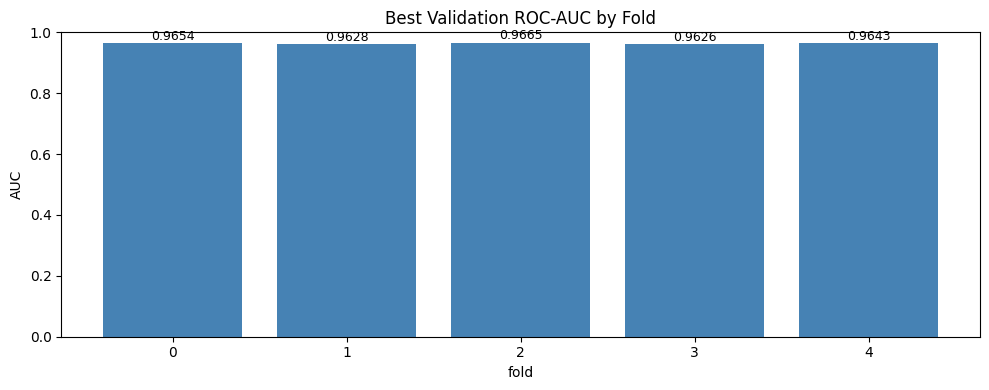

,fold,best_auc,best_epoch,train_rows,val_rows,weights
0,0,0.965411,7,29585,7442,/kaggle/working/fold_weights/best_model_fold_0...
1,1,0.962804,10,29619,7408,/kaggle/working/fold_weights/best_model_fold_1...
2,2,0.966465,10,29643,7384,/kaggle/working/fold_weights/best_model_fold_2...
3,3,0.962564,7,29686,7341,/kaggle/working/fold_weights/best_model_fold_3...
4,4,0.964269,10,29729,7298,/kaggle/working/fold_weights/best_model_fold_4...


In [13]:
cv_results_df = pd.DataFrame(cv_results)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.bar(cv_results_df['fold'].astype(str), cv_results_df['best_auc'], color='steelblue')
ax.set_title('Best Validation ROC-AUC by Fold')
ax.set_xlabel('fold')
ax.set_ylabel('AUC')
ax.set_ylim(0, 1)
for i, auc in enumerate(cv_results_df['best_auc']):
    ax.text(i, auc + 0.01, f'{auc:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

cv_results_df

# Inference on test soundscapes

In [ ]:
# ── GPU mel transform for inference (torchaudio = fast) ──────────────────
mel_transform = T.MelSpectrogram(
    sample_rate=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
    n_mels=N_MELS, f_min=FMIN, f_max=FMAX, power=2.0
).to(device)
amplitude_to_db = T.AmplitudeToDB(top_db=80).to(device)


def batch_audio_to_melspec(waveforms_gpu):
    """
    waveforms_gpu : (B, T) float32 tensor on GPU
    returns       : (B, 1, IMG_SIZE, IMG_SIZE) float32 on GPU
    """
    with torch.no_grad():
        mel      = mel_transform(waveforms_gpu)       # (B, N_MELS, T')
        mel      = amplitude_to_db(mel)               # log scale
        B        = mel.shape[0]
        mel_flat = mel.reshape(B, -1)                 # reshape not view
        mn       = mel_flat.min(dim=1).values.view(B, 1, 1)
        mx       = mel_flat.max(dim=1).values.view(B, 1, 1)
        mel      = (mel - mn) / (mx - mn + 1e-6)
        mel      = mel.unsqueeze(1)                   # (B, 1, N_MELS, T')
        mel      = F.interpolate(mel, size=(IMG_SIZE, IMG_SIZE),
                                 mode='bilinear', align_corners=False)
    return mel


def fast_load_window(filepath, end_sec, sr=SR, duration=DURATION):
    """Load a 5s window using soundfile — fast raw audio loading."""
    target    = sr * duration
    start_sec = max(end_sec - duration, 0)
    try:
        info    = sf.info(str(filepath))
        file_sr = info.samplerate
        start_f = int(start_sec * file_sr)
        end_f   = min(int((start_sec + duration) * file_sr), info.frames)
        y, _    = sf.read(str(filepath), start=start_f, stop=end_f,
                          dtype='float32', always_2d=False)
        if y.ndim == 2:
            y = y.mean(axis=1)
        if file_sr != sr:
            y = resample_poly(y, sr, file_sr).astype(np.float32)
    except Exception as e:
        print(e)
        y = np.zeros(target, dtype=np.float32)
    if len(y) < target:
        y = np.pad(y, (0, target - len(y)))
    return y[:target].astype(np.float32)


class SoundscapeDataset(Dataset):
    """Loads test soundscapes — workers return raw waveforms, GPU does mel."""
    def __init__(self, sample_sub, test_dir):
        self.items = []
        test_dir   = Path(test_dir)
        for _, row in sample_sub.iterrows():
            parts    = row['row_id'].split('_')
            end_time = int(parts[-1])
            stem     = '_'.join(parts[:-1])
            filepath = test_dir / f'{stem}.ogg'
            self.items.append((row['row_id'], filepath, end_time))
        exists = sum(1 for _, fp, _ in self.items if fp.exists())
        print(f'windows: {len(self.items):,}  |  files found: {exists:,}')

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        row_id, filepath, end_time = self.items[idx]
        y = fast_load_window(filepath, end_time)
        return torch.from_numpy(y), row_id

In [ ]:
# Build dataloader once
inf_ds = SoundscapeDataset(sample_sub, TEST_DIR)
inf_loader = DataLoader(inf_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

print(f'inference batches: {len(inf_loader)}')
print(f'ensemble over {len(fold_best_paths)} fold models')

all_row_ids = None
all_probs_sum = None
t0 = time.time()

for fold, best_path in enumerate(fold_best_paths):
    model = BirdModel().to(device)
    model.load_state_dict(torch.load(best_path, map_location=device))
    model.eval()

    fold_probs = []
    fold_row_ids = []

    with torch.no_grad():
        with autocast():
            for batch_idx, (waveforms, row_ids) in enumerate(inf_loader):
                waveforms = waveforms.to(device, non_blocking=True)
                images = batch_audio_to_melspec(waveforms)
                probs = torch.sigmoid(model(images)).float().cpu().numpy()
                fold_row_ids.extend(row_ids)
                fold_probs.append(probs)

                if fold == 0 and batch_idx % 20 == 0:
                    pct = (batch_idx + 1) / len(inf_loader) * 100
                    print(f'  {batch_idx + 1}/{len(inf_loader)} ({pct:.0f}%) elapsed={time.time() - t0:.0f}s')

    fold_probs = np.vstack(fold_probs)

    if all_row_ids is None:
        all_row_ids = fold_row_ids
        all_probs_sum = fold_probs
    else:
        assert all_row_ids == fold_row_ids, 'row_id order mismatch across folds'
        all_probs_sum += fold_probs

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

all_probs = all_probs_sum / len(fold_best_paths)
print(f'\ndone in {time.time() - t0:.0f}s  shape: {all_probs.shape}')

# Build and save submission

In [ ]:
sub_df = pd.DataFrame(all_probs, columns=SPECIES_COLS)
sub_df.insert(0, 'row_id', all_row_ids)
sub_df = sample_sub[['row_id']].merge(sub_df, on='row_id', how='left')
sub_df[SPECIES_COLS] = sub_df[SPECIES_COLS].fillna(0.0)

assert len(sub_df) == len(sample_sub), 'row mismatch'
assert list(sub_df.columns) == list(sample_sub.columns), 'column mismatch'
assert sub_df[SPECIES_COLS].isnull().sum().sum() == 0, 'nulls found'

print('=== sanity checks ===')
print(f'rows    : {len(sub_df):,}')
print(f'nulls   : {sub_df[SPECIES_COLS].isnull().sum().sum()}')
print(f'min prob: {sub_df[SPECIES_COLS].min().min():.4f}')
print(f'max prob: {sub_df[SPECIES_COLS].max().max():.4f}')
print('all checks passed ✅')

sub_path = OUTPUT_DIR / 'submission.csv'
sub_df.to_csv(sub_path, index=False)
print(f'\nsaved → {sub_path}')
sub_df.head()